In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/slt-examples


In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn_ext.mixture import PoissonMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
from plot import visualize_joint_confidence_regions
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


In [3]:
dgps_file = Path("./mixtures/poisson2d/data/dpgs.csv")
if dgps_file.exists(): # check if this data has already been generated
    print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
    if dgps_file.parent: # create parents dir if not already
        dgps_file.parent.mkdir(parents=True, exist_ok=True)

    dsids = ["regular", "e-singular", "singular"]
    dgps_raw = {
        "dsid"  : dsids,
        "m0" : np.array([5, 5, 5]), # probability of per site mutation if MSI1 tumor
        "m1" : np.array([1, 3, 5]), # probability of per site mutation if MSI2 tumor
        "w0" : np.array([0.75, 0.75, 0.75]), # probability of selecting a person with MSI1 tumor
    }
    dgps_raw["w1"] = 1-dgps_raw["w0"]
    pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
    print(f"File {dgps_file} created!.")

dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File mixtures/poisson2d/data/dpgs.csv created!.


,dsid,m0,m1,w0,w1
0,regular,5,1,0.75,0.25
1,e-singular,5,3,0.75,0.25
2,singular,5,5,0.75,0.25


In [4]:
from sklearn_ext.mixture import mixpoisson_sample

num_replications = 1000 # number of samples per sample size
max_samples = 5000 # number of samples per trial for each regime

for dsid in dgps["dsid"].unique():
    obs_file = Path(f"./mixtures/poisson2d/data/{dsid}.csv") # where we are going to store observations
    if obs_file.exists(): # check if this data has already been generated
        print(f"File {obs_file} exists, skipping random samples creation!.")
    else:
        if obs_file.parent: # create parents dir if not already
            obs_file.parent.mkdir(parents=True, exist_ok=True)
    
        results = {}
        for i in range(num_replications):
            dgp = dgps.query(f"dsid=='{dsid}'")
            mus = dgp[["m0", "m1"]].iloc[0].tolist()
            weights = dgp[["w0", "w1"]].iloc[0].tolist()
            samples = mixpoisson_sample(size=max_samples, weights=weights, mus=mus)
            results[f"r{i}"]=samples[0]
        
        
        data_df = pd.DataFrame(results)
        data_df.to_csv(obs_file, index=False)
        print(f"File {obs_file} created!.")
        

dsids = dgps["dsid"]
data = {}
for dsid in dsids:
    data[dsid]=pd.read_csv(f"./mixtures/poisson2d/data/{dsid}.csv", index_col=0).reset_index()

print(f"loaded {list(data.keys())} samples")

File mixtures/poisson2d/data/regular.csv created!.
File mixtures/poisson2d/data/e-singular.csv created!.
File mixtures/poisson2d/data/singular.csv created!.
loaded ['regular', 'e-singular', 'singular'] samples


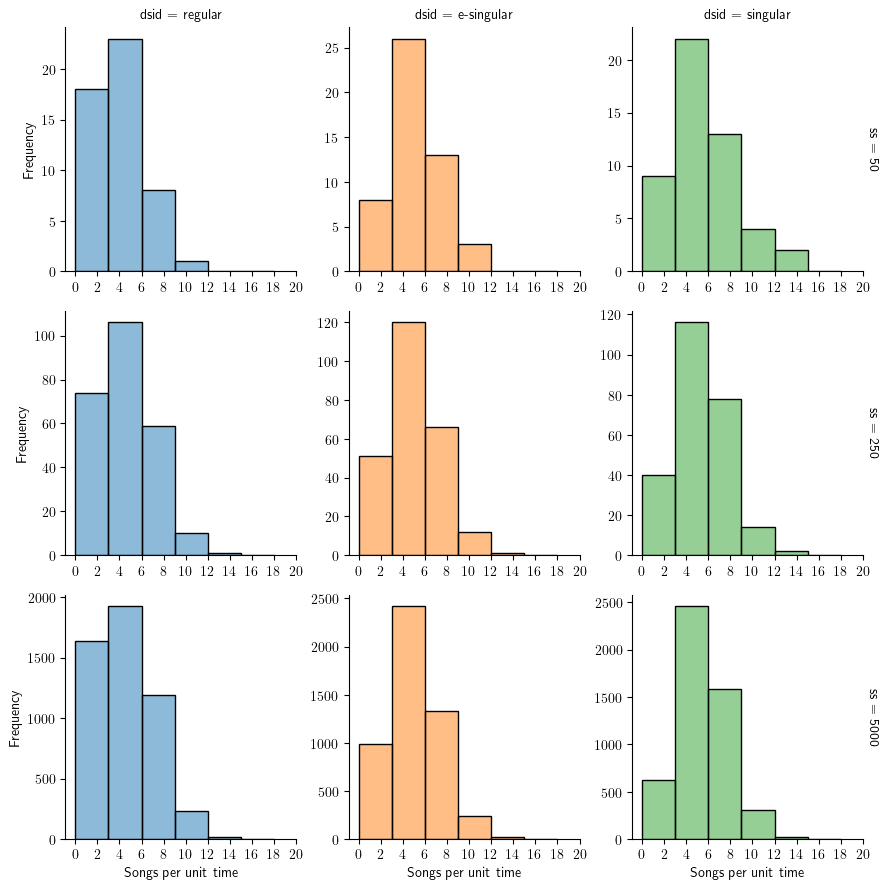

In [5]:
datasets = dgps["dsid"].unique()
ss_steps = [50, 250, 5000]

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "ss": [], "dsid": []} # raw data to initialize the plotting dataframe

for dsid in datasets:
    dgp = dgps.query(f"dsid == '{dsid}'")
    for ss in ss_steps:
        x = data[dsid].iloc[0:ss, 0]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["ss"]=np.append(plotdata["ss"], (np.ones(ss)*ss).astype(int))
        plotdata["dsid"]=np.append(plotdata["dsid"], [dsid for x in range(ss)])

plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "ss": int, "dsid": str})
g=sns.displot(plotdf, 
              x="x", col="dsid", row="ss", hue="dsid",
    binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": False, "sharex": False}, legend=False, palette=default_palette
)
g.set_axis_labels("Songs per unit time", "Frequency")

subtitles={}
for i in range(len(datasets)):
    ditem = dgps.iloc[i,:]
    subtitles[str(i)]=f'$\\alpha_1$={ditem["w0"].item()}, $p_1$={ditem["m0"].item()}, $p_2$={ditem["m1"].item()}'

# Only modify the top row of subplots (these have the column titles)
for ax in g.axes[0, :]:  # [0, :] means first row, all columns
    title = ax.get_title()
    if ' = ' in title:
        col_value = title.split(' = ')[1]
        if col_value in subtitles:
            # ax.set_title(f'{column_labels[col_value]}')
            # Set the main title
            ax.set_title(title, pad=25)
            
            # Add subtitle as text annotation
            ax.text(0.5, 1.05, subtitles[col_value], 
                   transform=ax.transAxes, 
                   ha='center', va='bottom',
                   fontsize=9, style='italic', color='gray')

for ax in g.axes.flat:
    ax.set_xticks(list(range(0, 22, 2)))
plt.savefig('./mixtures/poisson2d/data/dataset.png', dpi=300, bbox_inches='tight')
plt.show()